# 🚀 Machine Learning Reboot Challenge 🚀

Get ready to apply your knowledge in a hands-on experience with Airbnb data.

We'll work through:

🧹 Data Cleaning

🚦 Train-Test Split

👷 Preprocessing the proper way with pipelines

📈 Linear Regression 

🔁 Cross-Validation

🎯 Fine-Tuning

Let's dive in and bring these concepts to life! 🏊‍♀️🏊‍♂️

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 1. Understand the data 👏 and basic cleaning 🧹

In this challenge, we will use real Airbnb data. This data comes from many cities. We'll want to make our code easy to reuse. This way, we can work with different CSV files quickly, because we won't need to write new code for each csv!

### Loading the data

First up: ***Asheville, North Carolina***. The CSV file is available here: [🔗 link 🔗](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/asheville_airbnb.csv).

We're going to use a linear regression to predict the price of an Airbnb accomodation based on all the information we have about it!

👉 First, let's load the CSV file into a DataFrame called `df`.
<br><br>
<details><summary><i>💡  Hint</i></summary>

The first (unnamed) column in the CSV is actually an index column. That's the index that Pandas is creating by default, but it's not so helpful when we already have one!
    
To get rid of it, either use the `.reset_index()` method, or - **easier!** - use `index_col=0` when reading the CSV file.

Think about what index_col=0 is doing. Could we use `index_col` if our existing index was in the 3rd column?
</details>

In [39]:
url = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/asheville_airbnb.csv"

df = pd.read_csv(url, usecols=lambda col: not col.startswith("Unnamed"))

In [40]:
df

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,price,...,number_of_reviews,review_scores_rating,availability_365,instant_bookable,id,listing_url,scrape_id,last_scraped,name,description
0,28801,35.60670,-82.55563,Entire rental unit,Entire home/apt,2,1 bath,1.0,1.0,$120.00,...,90,4.50,285,f,108061,https://www.airbnb.com/rooms/108061,20220611041116,2022-06-11,Walk to stores/parks/downtown. Fenced yard/Pet...,Walk to town in ten minutes! Monthly rental in...
1,28806,35.57864,-82.59578,Entire guesthouse,Entire home/apt,2,1 bath,1.0,1.0,$100.00,...,359,4.58,179,t,155305,https://www.airbnb.com/rooms/155305,20220611041116,2022-06-11,Cottage! BonPaul + Sharky's Hostel,<b>The space</b><br />Private cottage located ...
2,28806,35.57864,-82.59578,Private room in home,Private room,2,2.5 shared baths,1.0,1.0,$66.00,...,67,4.52,0,t,156805,https://www.airbnb.com/rooms/156805,20220611041116,2022-06-11,"Private Room ""Ader"" at BPS Hostel",<b>The space</b><br />Private Rooms at Bon Pau...
3,28806,35.57864,-82.59578,Shared room in hostel,Shared room,1,2.5 shared baths,1.0,6.0,$33.00,...,306,4.71,199,t,156926,https://www.airbnb.com/rooms/156926,20220611041116,2022-06-11,"Mixed Dorm ""Top Bunk #1"" at BPS Hostel",This is a top bunk in the mixed dorm room<br /...
4,28806,35.57808,-82.63689,Private room in home,Private room,2,1 private bath,1.0,1.0,$45.00,...,51,4.98,78,f,197263,https://www.airbnb.com/rooms/197263,20220611041116,2022-06-11,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,28806,35.61922,-82.65641,Camper/RV,Entire home/apt,2,1 bath,NaN,1.0,$30.00,...,39,4.54,354,t,51838711,https://www.airbnb.com/rooms/51838711,20220611041116,2022-06-11,Rustic Camper minutes to Asheville,"Rustic, cozy, camper with lots of wood detaili..."
2852,28732,35.42588,-82.57732,Entire guesthouse,Entire home/apt,2,1 bath,NaN,1.0,$95.00,...,104,4.79,168,t,20910203,https://www.airbnb.com/rooms/20910203,20220611041116,2022-06-11,Mountain Cottage Retreat,Cozy guest cottage in prime location for visit...
2853,28806,35.61355,-82.66020,Entire guest suite,Entire home/apt,4,1 bath,1.0,2.0,$91.00,...,29,5.00,169,t,40617579,https://www.airbnb.com/rooms/40617579,20220611041116,2022-06-11,Relaxing country home right outside of Asheville.,A quiet country home just 15 minutes away from...
2854,28806,35.61215,-82.66623,Entire cabin,Entire home/apt,6,2 baths,3.0,3.0,$299.00,...,35,4.94,237,t,47531339,https://www.airbnb.com/rooms/47531339,20220611041116,2022-06-11,Barefoot Lodge at Dix Creek,Private cabin in rolling landscape that's 15 m...


👉 Investigate the dtypes of your DataFrame. Something is wrong. Do you see it?
<br><br>
<details><summary><i>💡  Solution</i></summary>

The `price` column is an object, not a float.

</details>

👉 Clean the column you identified.
<br><br>
<details><summary><i>💡  Hint</i></summary>

You'll need the [`.str.replace()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html) and the [`.astype()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.astype.html) methods. 
</details>


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   neighbourhood_cleansed  2856 non-null   int64  
 1   latitude                2856 non-null   float64
 2   longitude               2856 non-null   float64
 3   property_type           2856 non-null   object 
 4   room_type               2856 non-null   object 
 5   accommodates            2856 non-null   int64  
 6   bathrooms_text          2855 non-null   object 
 7   bedrooms                2693 non-null   float64
 8   beds                    2825 non-null   float64
 9   price                   2856 non-null   object 
 10  minimum_nights          2856 non-null   int64  
 11  number_of_reviews       2856 non-null   int64  
 12  review_scores_rating    2672 non-null   float64
 13  availability_365        2856 non-null   int64  
 14  instant_bookable        2856 non-null   

In [42]:
def str_replacer(
	df: pd.DataFrame,
	col: str,
	pattern: str | list[str] | dict[str, str | int | float],
	replacement: str | int | float | None = None,
) -> pd.DataFrame:
	"""
	Replace occurrences of patterns in a specified column of a DataFrame with replacement values.

	This function modifies the DataFrame in place by using pandas' string replace method
	on the specified column. It checks if the input is a DataFrame before proceeding.

	Parameters
	----------
	df : pd.DataFrame
		The DataFrame containing the column to modify.
	col : str
		The name of the column in which to perform the replacement.
	pattern : str | list[str] | dict[str, str | int | float]
		The pattern(s) to search for and replace. Can be:
		- A single string pattern.
		- A list of string patterns. If replacement is a single value, it is applied to each pattern.
		- A dictionary mapping patterns to their respective replacements for batch replacement.
	replacement : str | int | float | None, optional
		The value to replace the pattern(s) with. Required if pattern is a str or list[str].
		Ignored if pattern is a dict. It will be converted to a string for replacement.

	Returns
	-------
	pd.DataFrame
		The modified DataFrame with the replacements applied.
	"""
	# Check if input is a DataFrame, raise error if not
	if not isinstance(df, pd.DataFrame):
		raise ValueError("Input must be a pandas DataFrame")

	# Convert column to string if it's not already
	if df[col].dtype != "object":
		df[col] = df[col].astype(str)

	# Handle dictionary pattern: replace each key with its value
	if isinstance(pattern, dict):
		for pat, repl in pattern.items():
			df[col] = df[col].str.replace(pat, str(repl))
	# Handle list of patterns: replace each with the single replacement value
	elif isinstance(pattern, list):
		if replacement is None:
			raise ValueError("Replacement must be provided when pattern is a list")
		for pat in pattern:
			df[col] = df[col].str.replace(pat, str(replacement))
	# Handle single string pattern: replace with the replacement value
	else:
		if replacement is None:
			raise ValueError("Replacement must be provided when pattern is a string")
		df[col] = df[col].str.replace(pattern, str(replacement))

	return df


In [43]:
df = str_replacer(df=df, col="price", pattern=["$", ","], replacement="")
df["price"] = df["price"].astype(float)


#### Check your code

In [44]:
from nbresult import ChallengeResult

result = ChallengeResult("df", df_columns=df.columns, price_dtype=df["price"].dtype)
result.write()

print(result.check())

### Target distribution

👉 Take a look at the distribution of the target. Also check out its minimum and maximum values.
<br><br>
<details><summary><i>💡  Hint</i></summary>

Use the `.hist()` method of a pd.Series. You can apply it to your target column. 
</details>


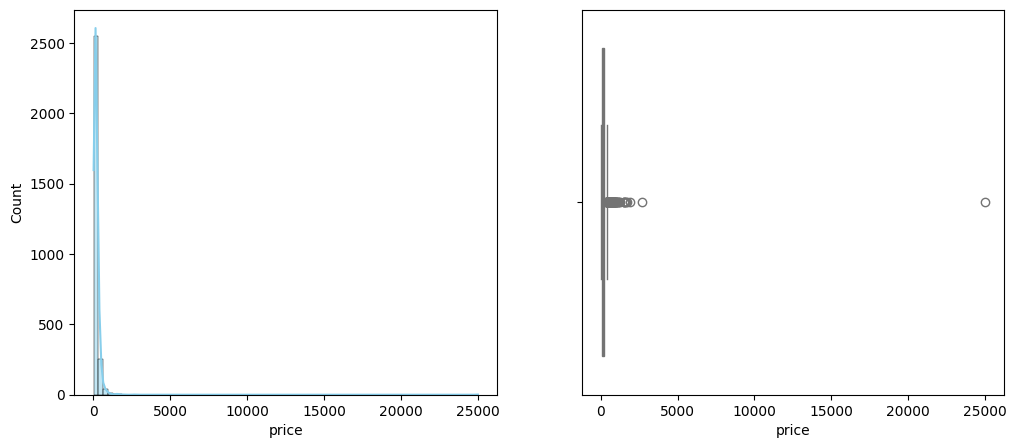

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["price"], bins=80, kde=True, color="skyblue", ax=axes[0])
sns.boxplot(x=df["price"], color="lightgreen", ax=axes[1])

plt.show()


In [46]:
df["price"].describe()

count     2856.000000
mean       195.723739
std        491.389346
min         19.000000
25%         98.000000
50%        140.000000
75%        225.000000
max      24999.000000
Name: price, dtype: float64

Looks quite skewed! We're going to focus on Airbnb listings priced between 50 and 1500 dollars (both included).

👉 Create a DataFrame named `reduced` with only listings priced between 50 and 1500.

In [47]:
reduced = df[(df["price"] >= 50) & (df["price"] <= 1500)]

#### Check your code

In [49]:
from nbresult import ChallengeResult

result = ChallengeResult(
	"reduced",
	reduced_min=reduced["price"].min(),
	reduced_max=reduced["price"].max(),
	reduced_shape=reduced.shape,
)
result.write()

print(result.check())

### Clean other columns

👉 Inspect your `reduced` DataFrame. 

There are two columns that we will need to change a bit before we start our modeling. Do you see which ones and why?
<br><br>
<details><summary><i>💡  Solution</i></summary>

- The `bathrooms_text` column seems to have mainly numeric information, but in a text format.
- The `instant_bookable` column has `t` and `f` values. It would be easier for us to have just 1s and 0s instead.
</details>


Let's start with the first problematic column. 

👉 Have a look at the unique values in the column.

In [50]:
reduced["bathrooms_text"].value_counts()

bathrooms_text
1 bath              1410
2 baths              567
1 private bath       209
2.5 baths            139
3 baths              134
1.5 baths             98
1 shared bath         67
3.5 baths             51
4 baths               38
1.5 shared baths      10
4.5 baths             10
2 shared baths         9
5 baths                8
6 baths                6
5.5 baths              3
2.5 shared baths       2
Half-bath              2
0 shared baths         1
0 baths                1
7 baths                1
Name: count, dtype: int64

In [51]:
print(f"Bathrooms: {reduced['bathrooms_text'].nunique()}")
print(f"Instant Bookable: {reduced['instant_bookable'].unique()}")

Bathrooms: 20
Instant Bookable: ['f' 't']


In [52]:
reduced["bathrooms_text"].dtype
reduced["instant_bookable"].dtype


dtype('O')

Here is the cleaning function (a little 🎁 for you), but you will have to _apply_ it to the DataFrame yourself.

In [53]:
def extract_number(df: pd.DataFrame, col: str, new_column_name: str) -> pd.DataFrame:
	"""
	Parameters
	----------
	df : pd.DataFrame
		The input DataFrame containing the column to process.
	col : str
		The name of the column from which to extract numbers. Must be a string column.
	new_column_name : str
		The name for the new column to store the extracted numeric values.

	Returns
	-------
	pd.DataFrame
		The modified DataFrame with the new numeric column added.

	Raises
	------
	ValueError
		If the input is not a pandas DataFrame.
	KeyError
		If the specified column does not exist in the DataFrame.

	"""
	if not isinstance(df, pd.DataFrame):
		raise ValueError("Input must be a pandas DataFrame")

	if col not in df.columns:
		raise KeyError(f"Column '{col}' does not exist in the DataFrame")

	if df[col].dtype != "object":
		df[col] = df[col].astype(str)

	# Replace "half" with "0.5" before extracting numbers
	temp_col = df[col].str.lower().str.replace("half", "0.5")

	pattern = r"(\d+(?:\.\d+)?)"
	numbers = temp_col.str.extract(pattern, expand=False)
	numeric_column = pd.to_numeric(numbers, errors="coerce")
	df[new_column_name] = numeric_column
	return df

👉 Use the function to clean the column, and save the result back in the same column.

In [54]:
df = extract_number(df=df, col="bathrooms_text", new_column_name="bathrooms")

Now, let's work on the other column. There are multiple ways to transform the values into 0s and 1s. 

👉 Pick the one you're comfortable with (as long as it's not a for loop...) and use it to clean the column.
<br><br>
<details><summary><i>💡  Hint</i></summary>
    
- [`pandas.Series.map()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html) with a mapping dictionary
- [`pandas.Series.apply()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.apply.html) with a lambda function (not recommended on large datasets because it is slow)
- [`numpy.where()`](https://numpy.org/doc/stable/reference/generated/numpy.where.html)
- Boolean indexing
</details>

In [56]:
df["instant_bookable"] = df["instant_bookable"].map({"t": 1, "f": 0})

#### Check your code

In [57]:
from nbresult import ChallengeResult

result = ChallengeResult(
	"cleaned",
	reduced_shape=reduced.shape,
	bathrooms_text_dtype=reduced["bathrooms_text"].dtype,
	instant_bookable_dtype=reduced["instant_bookable"].dtype,
)
result.write()

print(result.check())

### Make a reusable function

Great! We have done all the cleaning. But what if later we want to do this for another CSV file?

👉 Create a `df_load_and_clean` function that combines all the previous steps. If all goes well, you should not be doing much more than just copy-pasting from what you did before.

In [ ]:
def df_load_and_clean(url):
	"""Loads a CSV from the `url` provide and does the basic cleaning"""
	# Read the CSV into a dataframe

	# Clean and convert price into a float

	# Keep only prices between 50 and 1500

	# Clean and convert bathrooms_text into a float

	# Convert instant_bookable into 0s and 1s

	# Return the result

#### Check your code 

In [ ]:
new_df = df_load_and_clean(url)

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult(
	"load_and_clean",
	new_df=new_df,
	new_shape=new_df.shape,
	price_dtype=new_df["price"].dtype,
	bathrooms_text_dtype=new_df["bathrooms_text"].dtype,
	instant_bookable_dtype=new_df["instant_bookable"].dtype,
)
result.write()

print(result.check())

Great! You now have a function that loads the data for you, and does the cleaning for you. Time to go to the next step!

## 2. Train-Test Split 🚦

### Select the relevant columns

Look at the columns and pick only the ones that can help us with our linear regression task. 

Hint: some columns really won't have added value for our regression task. Drop those.

👉 Create `X` and `y` starting from `new_df`

In [ ]:
# YOUR CODE HERE

#### Check your code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult(
	"x_and_y", x_shape=X.shape, y_shape=y.shape, x_columns=X.columns
)
result.write()

print(result.check())

### Split in train and test set

👉 Split your data in a train and a test set.

Let's do a 80/20 split.

And let's use a random state of `42`. (In your final pipeline you'd want to remove the random state, but here it will help us to compare our results.)

In [ ]:
from sklearn.model_selection import train_test_split

pass  # YOUR CODE HERE

## 3. Preprocessing 👷

We already did some basic cleaning, but we'll need some preprocessing steps. Let's do those using `scikit-learn`. We will immediately do our preprocessing using pipelines.

❓ Why do we want to use pipelines?

<details>
  <summary><i>Answer</i>
  </summary>

  1. They allow us to structure our preprocessing nicely
  2. They make it easy to fit our preprocessing to the training set and to transform the training set, the test set, and any new data we want to feed into our model
  3. They will allow us to properly cross-validate and grid search a full pipeline with preprocessing and model

</details>

By default preprocessors output NumPy arrays. We prefer to output Pandas DataFrames because they are easier to work with.

You can use the `.set_output(transform='pandas')` method of your transformer to keep the output in a DataFrame format instead of a numpy array.

💡 But instead of doing that for each transformer, you can also set this globally. Run the cell below.

In [ ]:
from sklearn import set_config

set_config(transform_output="pandas")

### Numeric features

👉 Create a list with the numeric features

In [ ]:
# Tip: print your columns and then copy-paste them to form your new list
# It's easier to remove columns from a list than to type (and fix typos)
X_train.columns

In [ ]:
num_cols = []  # YOUR LIST HERE

#### Missing values

👉 Examine the missing values. How many columns have missing values? How many values are missing?

In [ ]:
# YOUR CODE HERE

We'll have to do something about these missing values. Which strategies can you apply?
<br><br>
<details><summary><i>💡  Solution</i></summary>

- **Drop the columns** with missing values, but we only have a small percentage of missing values. So let's not do that.
- **Drop the rows** with missing values. Quick and dirty, but for most columns we actually have the values. So let's not do that.
- **Impute missing values**: fill in the blanks.
</details>

Look at the columns with missing values. What would be the best imputation strategy for each? Check each column's unique values to make up your mind.
<br><br>
<details><summary><i>💡  Solution</i></summary>

- `bedrooms`: if there is no data, we could assume there is no separate bedroom. So impute with 0s.
- `beds`: if there is no data, we could assume there are no beds. So impute with 0s.
- `review_scores_rating`: if there is no data, we could assume that there is no rating yet, and we could impute with the average rating. (You could make a case for other strategies in this case. A [`KNNImputer`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html) could be interesting here, but we'll stick to our simple imputing strategy for now.)
</details>

In [ ]:
X_train.head()

👉 Let's prepare our imputers.

Because we have two different strategies, you'll need two separate imputers: one for the 0 imputation, and one for the mean imputation!

Name them `zero_imputer` and `mean_imputer`.

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
# Instantiate your zero_imputer and mean_imputer

# YOUR CODE HERE

# Make two lists zero_imputer_cols and mean_imputer_cols

# YOUR CODE HERE

# Each list should contain the column names that will be zero / mean imputed

# YOUR CODE HERE

# This will come in handy later when we will create our pipeline

# YOUR CODE HERE

Now, we can combine our two imputers in a column transformer as a first step in our pipeline.

👉 Make a column transformer called `num_imputer` to :
- zero impute the columns we defined above
- mean impute all other columns unchanged (hint: think of the `remainder` parameter)

(The other columns didn't have missing values, but we might use our pipeline for other cities too. That's why we'll mean impute all other columns for now.)

You can choose between using the class based approach (`Pipeline`, `ColumnTransformer`) or the `make_pipeline`, `make_column_transformer` shortcut functions.

In [ ]:
from sklearn.compose import ColumnTransformer, make_column_transformer

# Create num_imputer
pass  # YOUR CODE HERE

# Display num_imputer to check
num_imputer

#### Scale the numerical features

👉 Which columns do you need to scale?

Also check the distributions to see which scaler to choose. 👉 Run the cell below.

In [ ]:
X_train[num_cols].hist(figsize=(15, 10));

👉 Instantiate an appropriate scaler. For now, to go fast, we'll scale all our selected columns with a RobustScaler. Later we should come back to this step, and choose the most appropriate scaler for each column.



In [ ]:
from sklearn.preprocessing import RobustScaler

# Instantiate your scaler. Call it `scaler`
# Pro tip: use the .set_output(transform='pandas') method
pass  # YOUR CODE HERE

We have created an imputer for our numerical features, and a scaler. We can now create a pipeline to combine both steps.

👉 Make a pipeline called `num_pipe` to :
- impute missing values using our `num_imputer`
- scale features using our `scaler`

You can choose between using the class based approach (`Pipeline`, `ColumnTransformer`) or the `make_pipeline`, `make_column_transformer` shortcut functions.

In [ ]:
from sklearn.pipeline import Pipeline, make_pipeline

# Create num_pipe:
# It should first use your num_imputer and then your scaler
pass  # YOUR CODE HERE

# Display num_pipe to check your pipeline
num_pipe

#### Check your code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult(
	"scaler",
	num_cols=num_cols,
	X_train_scaled=num_pipe.fit_transform(X_train[num_cols]),
)
result.write()

print(result.check())

### One Hot Encode the categorical features

👉 Which columns do you need to encode?

In [ ]:
cat_cols = []  # YOUR LIST HERE

Good practice: check how many different values you have in each of the columns.

👉 Run the cell below to have a look.

Remember that every value will become a column in our X after the encoding.

In [ ]:
for col in cat_cols:
	display(pd.DataFrame(X_train[col].value_counts()))

It's clear that for one of these columns we'll have to be a bit smart when encoding. Otherwise we'll have way too many columns in our end result.

👉 Find the right parameter for the OneHotEncoder to limit the number of created columns.
<br><br>
<details><summary><i>💡  Solution</i></summary>
There are two candidates:
<ul>
    <li><strong>max_categories</strong>
    </li>
    <li><strong>min_frequency</strong>
    </li>
</ul>
    Let's use <code>max_categories=10</code> for our first iteration. We can change this later.
</details>

👉 Now create a one hot encoder for your categorical features

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Instantiate your OneHotEncoder. Call it `encoder`
# Use the .set_output() method again!
pass  # YOUR CODE HERE

We have created a OneHotEncoder for our categorical features.

Because we didn't have any missing values for our categorical features, that was enough for our case. But remember: we might use our pipeline for other cities too. So it's better to add an imputer for missing values.

👉 Make a pipeline called `cat_pipe` to :
- impute missing values with the most frequent value
- scale features using our `scaler`

Use a different approach than you used in your `num_pipe` (class based vs shortcut function)

In [ ]:
from sklearn.pipeline import Pipeline, make_pipeline

# Create cat_pipe:
# It should first apply an imputer and then your scaler
pass  # YOUR CODE HERE

# Display cat_pipe to check your pipeline
cat_pipe

#### Check your code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult(
	"encoder",
	cat_cols=cat_cols,
	X_train_encoded=cat_pipe.fit_transform(X_train[cat_cols]),
)
result.write()

print(result.check())

### Bringing numerical and categorical features back together

We have a pipeline for the numerical and a one-hot-encoder for the categorical features. Let's bring them together.

👉 Make a new column transformer called `preprocessor` that will pipe the numerical features through our `num_pipe`, and the categorical features through our `cat_pipe`.

If in the previous step you used the class based approach (`Pipeline`, `ColumnTransformer`), then switch to the `make_pipeline`, `make_column_transformer` shortcut functions this time. Or the other way around. Just make sure you switch 🙃

In [ ]:
# Create preprocessor:
# Use num_pipe for the num_cols and cat_pipe for the cat_cols
pass  # YOUR CODE HERE

# Display preprocessor to check your pipeline
preprocessor

Do you see the difference between using the class based approach and the `make_***` shortcut functions? 

The class based approach let's you define nice names for the different steps. If you use `make_***`, scikit-learn will determine the name for you. This becomes especially visible when using `ColumnTransformer`.

Let's recap what we did:


- For the **numerical** columns (our `num_cols`):
  - Firstly, we imputed missing values using our imputers:
    - `zero_imputer` for features `bedrooms` and `beds`
    - `mean_imputer` for features `review_scores_rating`
    - The other columns did not have any missing values, but because we are going to use our preprocessor also for other cities, we put all of them also through the `mean_imputer`
  - Secondly, we scaled all numerical features with our `scaler`
  
  
-  For the **categorical** columns (our `cat_cols`):
   - Impute missing values. We didn't have any in our data, but again we want it to work for other cities too. We impute the most frequent value.
   - Encode with our `encoder`
  
A visual summary of what our pipeline looks like:

<img alt="Pipeline schema" src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/ml-reboot-pipeline.png" width=700>


Let's use our pipeline to preprocess our train and test sets.

Store them in X_train_preprocessed and X_test_preprocessed.

You will probably run into a couple of errors. Most probably they come from the OneHotEncoder. Up to you to find the right parameters for your OneHotEncode and change them above.

In [ ]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
X_train_preprocessed.shape, X_test_preprocessed.shape

If you get a UserWarning about unknown categories when preprocessing the test set: that is normal. Do you know why?
<br><br>
<details><summary><i>💡  Solution</i></summary>
    Remember our OneHotEncoder?
    <br>
    It encodes all the categories in the train set into columns with 1s and 0s.
    <br>
    It's possible that the encoder will encounter categories in the test set that it hasn't seen during the fit. For those rows, all encoded columns will contain 0s (because we chose <code>handle_unknown='ignore'</code>).
</details>

#### Check your code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult(
	"pipeline",
	X_train_preprocessed=X_train_preprocessed,
	X_test_preprocessed=X_test_preprocessed,
	X_train_to_test_pipeline=preprocessor.fit_transform(X_train),
	X_test_to_test_pipeline_not_fitted_on_test=preprocessor.transform(X_test),
)
result.write()

print(result.check())

🚀 Congratulations! You built your complete preprocessing pipeline.

## 4. Modelling 📈

Now that we have a pipeline to preprocess our data, we can finally get into modelling.

We will use the [`ElasticNet`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html#elasticnet) linear regression model, that will give us some parameters to play with in the next phase 🎯. 

Do you remember what the ElasticNet model is?
<br><br>
<details><summary><i>💡  Solution</i></summary>
    ElasticNet is a linear regreession, with a mixture of L1 and L2 regularization. It basically combines Ridge and Lasso regression.
</details>

👉 Instantiate an ElasticNet model and call it `elastic`

In [ ]:
from sklearn.linear_model import ElasticNet

# Instantiate a model and call it `elastic`
pass  # YOUR CODE HERE

Now we want to obtain a cross validated score.

Have a look at the cell below, and run the cell.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_results = cross_val_score(elastic, X_train_preprocessed, y_train, cv=5)
cv_results.mean()

**But we did something wrong! 😱**

👉 Take a moment to think where we made a mistake in the cell above before you read further.
<br><br>
<details><summary><i>💡  Solution</i></summary>
When we cross-validated, we only cross-validated the modeling step.

In the cross-validation, our training set is split again in a train and a validation set (and that 5 times in our case).

But our preprocessing steps were applied to the whole training set, **before** this second split. 
    
This means that we have data leakage between our train and validation set inside the cross-validation.

Ideally, for every fold of our cross-validation, we want to:

  - Fit all preprocessing steps on the train set
  - Transform the train and the validation set
  - Train the model on the train
  - Score on the validation set

The cross-validation we did so far, did not correctly do the preprocessing.
</details>

👉 How could we solve this? Take a moment to think about it.
<br><br>
<details><summary><i>💡  Solution</i></summary>
We could make a pipeline with all our preprocessing steps + our model, and cross-validate this full pipeline instead of just the model.
    
That way, the cross-validation will each time fit the preprocessor and the model only on the training set.
</details>

👉 Create an `elastic_pipe` by combining your `preprocessing` pipeline with the `elastic` model

In [ ]:
# Create a pipeline with your preprocessor and your model
# Call it `elastic_pipe`
pass  # YOUR CODE HERE

# Display elastic_pipe to check your pipeline
elastic_pipe

We can now use this pipeline in our modelling steps.

👉 Cross-validate `elastic_pipe` and store your average score in `cv_score`

Remember we don't need to separately preprocess our training data. Because we combined preprocessing and model into one pipeline, scikit-learn will do the preprocessing for us.

In [ ]:
# Cross-validate it on your training set
pass  # YOUR CODE HERE

# Save the average score in a variable `cv_score`
pass  # YOUR CODE HERE

You might get a few UserWarnings about unknown categories. That is normal. Do you remember why?
<br><br>
<details><summary><i>💡  Answer</i></summary>

Remember our OneHotEncoder?

It encodes all the categories in the train set into columns with 1s and 0s.
    
It can happen that in the validation set the encoder encounters categories that it hasn't seen during the fit. In that cases all encoded columns will have 0s (because we chose `handle_unknown='ignore'`.

We get multiple warnings: one for each fold where this happens.
</details>

#### Check your code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult("linreg_pipe", cv_score=cv_score)
result.write()

print(result.check())

Back to our results.

What does this `cv_score` represent? What metric are we using here? Are you happy with this score?
<br><br>
<details><summary><i>💡  Solution</i></summary>
    For regression models, the default score in scikit-learn is the R<sup>2</sup>.<br>
    To know if this is good, we need a baseline.
</details>

Let's create a baseline model. What would a good baseline be for this task?
<br><br>
<details><summary><i>💡  Solution</i></summary>
    For regression models, the simplest thing we can do is to simply use the mean as the prediction.
</details>

To compare our baseline model, we should also cross-validate it, just like our real model. 

This is where scikit-learn's [dummy models](https://scikit-learn.org/stable/api/sklearn.dummy.html) come in handy. They provide us with a way to use a simple mean calculation as a real scikit-learn model.

👉 Have a look at the cell below, and figure out what we're doing.

In [ ]:
from sklearn.dummy import DummyRegressor

# Create a baseline_pipe using the baseline model
baseline_pipe = make_pipeline(preprocessor, DummyRegressor(strategy="mean"))

# Cross-validate on the preprocessed training set
baseline_cv_results = cross_val_score(baseline_pipe, X_train, y_train, cv=5)

# Save the average score in a variable `cv_score`
baseline_cv_score = baseline_cv_results.mean()
baseline_cv_score

Is our model performing better than the baseline?

👉 Save your answer "yes" or "no" in a variable `better_than_baseline`.

In [ ]:
better_than_baseline = None  # Choose between "yes" or "no"

#### Check your code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult("baseline_model", better_than_baseline=better_than_baseline)
result.write()

print(result.check())

Now that we are this far, it's time to take a step back.

What did we do so far:
- We created a function `df_load_and_clean()` to **load our data and do some basic cleaning**
- We **split** our data in train and test sets
- We created a **preprocessor** using pipelines:
  - Imputing missing values
  - Scaling numerical features
  - Encoding categorical features
  - Combine numerical and categorical features back in one big preprocessed DataFrame
- We instantiated a **model** and added it to the pipeline
- We **cross-validated** the whole pipeline
- We compared our model to a **baseline** model (taking the mean)

## 5. Fine-Tuning 🎯 

With pipelines, we can now start fine-tuning the complete pipeline


In our pipeline we use the ElasticNet model. What are the hyperparameters we can tune? Have a look at the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html#elasticnet).
<br><br>
<details><summary><i>💡  Solution</i></summary>

`alpha`: the amount of regularization we want

`l1_ratio`: how much L1 regularization we want (the rest will be L2)
</details>

👉 Fine-tune your `elastic_pipe` and store the result in `pipe_grid_score`

In [ ]:
# First find the name of the correct parameter to tune
elastic_pipe.get_params()

In [ ]:
# Let's suppress those UserWarnings we talked about before.
import warnings

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

warnings.filterwarnings("ignore", category=UserWarning)

# Instantiate a hyperparameter grid with these values:
#     'alpha': [0.1, 1.0, 10.0]
#     'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]
pass  # YOUR CODE HERE

# Instantiate a GridSearchCV with linreg_pipe and your hyperparameter grid
pass  # YOUR CODE HERE

# Fit the grid search on X_train, y_train
pass  # YOUR CODE HERE

👉 Save the score of the best estimator in grid_best_score and display it

In [ ]:
# YOUR CODE HERE

👉 Save the hyperparameters of the best estimator in grid_best_score and display them

In [ ]:
# YOUR CODE HERE

👉 Finally, use the best model and score it on the test set, save it into `grid_test_score`

Do NOT train a new model, it's not needed: you can get it out of your grid search results!

In [ ]:
# YOUR CODE HERE

👉 How many models did the GridSearch train to get to its result?

Save your answer in a variable `nb_trainings`

In [ ]:
# YOUR CODE HERE

#### Check your code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult(
	"grid_search",
	best_params=grid_best_params,
	best_score=grid_best_score,
	test_score=grid_test_score,
	training_count=training_count,
)
result.write()

print(result.check())

## How could we take this further?

You might have noticed that the grid search at the end was a bit basic.

And to be honest: finding better parameters is a bit of a challenge for this model. The models seems to be underfitting.

Extra things we could try out:

- **Feature engineering**: add extra features that can make your model perform better
  Some possibilities:
  - `price` divided by `bedrooms`
  - Calculate the distance from the city center (which you could approximate by the average of the latitude and longitude of all airbnb's)
  - To use those in your pipelines, you'll need to look into custom transformers (check the Workflow lecture)
- **Try out other models**: a `KNNRegressor` or an `SVR`
- **Grid search (or Randomized search) the hyperparameters of those models** (e.g. `n_neighbours`, `kernel`, `C`)
- **Add hyperparameters of the preprocessors to your grid search** (e.g. the imputation strategy)

**Don't do this for now, because we will be doing similar things in the next unit! 🚀**

🏁 Congratulations! You made it! You did a complete reboot of the Machine Learning workflow!

💾 Don't forget to `git add/commit/push` your notebook...